# Predição de Evasão Escolar

In [1]:
# ---------------------------------------------------------
# 1. IMPORTAÇÕES E REPRODUTIBILIDADE
# ---------------------------------------------------------
import os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_auc_score, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IS_COLAB  = True
    PATH_BASE = '/content/drive/MyDrive'
except (ModuleNotFoundError, ImportError):
    IS_COLAB  = False
    PATH_BASE = '.'

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style='whitegrid')


if IS_COLAB:
    # Caminho correto no Google Drive
    PATH_DATASET = '/content/drive/MyDrive/Datasets/evasão/dataset_2017_a_2022_concluidos_evadidos_v3.csv'
    OUTPUT_DIR   = f'{PATH_BASE}/Colab Notebooks/Artigo/outputs'
else:
    PATH_DATASET = './Dataset/dataset_2017_a_2022_concluidos_evadidos_v3.csv'
    OUTPUT_DIR   = './outputs'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Dataset : {PATH_DATASET}')
print(f'Outputs : {OUTPUT_DIR}')

# Verificar se o arquivo existe
if os.path.exists(PATH_DATASET):
    print("✅ Arquivo encontrado!")
else:
    print("❌ Arquivo NÃO encontrado! Verifique o caminho.")

Mounted at /content/drive
Dataset : /content/drive/MyDrive/Datasets/evasão/dataset_2017_a_2022_concluidos_evadidos_v3.csv
Outputs : /content/drive/MyDrive/Colab Notebooks/Artigo/outputs
✅ Arquivo encontrado!


In [2]:
# ---------------------------------------------------------
# 2. CARREGAMENTO E DIAGNÓSTICO
# ---------------------------------------------------------
df = pd.read_csv(PATH_DATASET)
df = df[df['idade_ingresso'] < 100].copy()
print(f'Registros: {len(df)} | Taxa de evasão: {df["evadiu"].mean()*100:.1f}%')

sem_componentes = df['total_componentes_1ano'].isnull()
sem_taxa        = (~sem_componentes) & df['taxa_aprovacao_1ano'].isnull()

print(f'\nGrupo A — sem dados acadêmicos  : {sem_componentes.sum():4d} ({sem_componentes.mean()*100:.1f}%) | evasão: {df.loc[sem_componentes,"evadiu"].mean()*100:.1f}%')
print(f'Grupo B — só trancamentos        : {sem_taxa.sum():4d} ({sem_taxa.mean()*100:.1f}%) | evasão: {df.loc[sem_taxa,"evadiu"].mean()*100:.1f}%')
print(f'Com dados completos              : {(~sem_componentes & ~sem_taxa).sum():4d} ({(~sem_componentes & ~sem_taxa).mean()*100:.1f}%) | evasão: {df.loc[~sem_componentes & ~sem_taxa,"evadiu"].mean()*100:.1f}%')

Registros: 9167 | Taxa de evasão: 56.7%

Grupo A — sem dados acadêmicos  :  495 (5.4%) | evasão: 100.0%
Grupo B — só trancamentos        : 1144 (12.5%) | evasão: 99.8%
Com dados completos              : 7528 (82.1%) | evasão: 47.3%


In [3]:
# ---------------------------------------------------------
# 3. ENGENHARIA DE FEATURES
# ---------------------------------------------------------

# --- Features ingresso ---
df['prazo_ano'] = df['prazo_conclusao'] // 10
df['prazo_sem'] = df['prazo_conclusao'] % 10
df['duracao_maxima'] = (
    (df['prazo_ano'] - df['ano_ingresso']) * 2
    + (df['prazo_sem'] - df['periodo_ingresso'])
)
df['vulnerabilidade']    = df['escola_publica'] + df['ppi'] + df['baixa_renda']
df['noturno_vulneravel'] = (df['turno_curso'] == 'Noturno').astype(int) * df['baixa_renda']
df['curso_longo_ppi']    = (df['duracao_maxima'] > 10).astype(int) * df['ppi']

# --- Flags de ausência de dados  ---
df['sem_dados_academicos'] = df['total_componentes_1ano'].isnull().astype(int)

# sem_aprovacao_reprovacao: cursou apenas trancamentos
df['sem_aprovacao_reprovacao'] = (
    (~df['total_componentes_1ano'].isnull()) &
    df['taxa_aprovacao_1ano'].isnull()
).astype(int)

# --- Target multiclasse ---
def classificar_evasao(row):
    if row['evadiu'] == 0: return 0
    return 1 if row['periodo_atual'] <= 4 else 2
df['target_mc'] = df.apply(classificar_evasao, axis=1)

print('Features criadas:')
print(f'  duracao_maxima          : min={df["duracao_maxima"].min()}, max={df["duracao_maxima"].max()}')
print(f'  sem_dados_academicos    : {df["sem_dados_academicos"].sum()} alunos')
print(f'  sem_aprovacao_reprovacao: {df["sem_aprovacao_reprovacao"].sum()} alunos')

Features criadas:
  duracao_maxima          : min=2, max=24
  sem_dados_academicos    : 495 alunos
  sem_aprovacao_reprovacao: 1144 alunos


In [4]:
# ---------------------------------------------------------
# 4. FEATURES E SPLITS
#
# ---------------------------------------------------------
features_categoricas = [
    'contexto_temporal', 'sexo', 'turno_curso',
    'area_curso', 'modalidade_educacao',
    'cor_raca', 'categoria_ingresso'
]
features_numericas = [
    'idade_ingresso', 'duracao_maxima', 'vulnerabilidade',
    'total_componentes_1ano',
    'taxa_aprovacao_1ano',
    'reprovacoes_1ano',
    'reprovacoes_falta_1ano',
    'media_geral_1ano',
    'pior_nota_1ano',
    'media_frequencia_1ano',
    'total_faltas_1ano'
]
features_binarias = [
    'necessidade_especial', 'escola_publica', 'ppi', 'baixa_renda',
    'periodo_ingresso', 'noturno_vulneravel', 'curso_longo_ppi',
    'teve_trancamento_1ano',
    'sem_dados_academicos',
    'sem_aprovacao_reprovacao'
]

y = df['evadiu']
X = df[features_categoricas + features_numericas + features_binarias].copy()

X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Dev: {len(X_dev)} | Test: {len(X_test)}')
print(f'Total features: {len(features_categoricas + features_numericas + features_binarias)}')

Dev: 7333 | Test: 1834
Total features: 28


In [5]:
# ---------------------------------------------------------
# 5. PRÉ-PROCESSAMENTO
# ---------------------------------------------------------
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ]), features_numericas),
    ('cat', OneHotEncoder(
        drop='first', handle_unknown='ignore', sparse_output=False
    ), features_categoricas),
    ('bin', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0))
    ]), features_binarias)
])

X_dev_proc  = preprocessor.fit_transform(X_dev)
X_test_proc = preprocessor.transform(X_test)
print(f'Dimensão após encoding: {X_dev_proc.shape[1]} features')

Dimensão após encoding: 48 features


In [6]:
# ---------------------------------------------------------
# 6. MODELO MLP
# ---------------------------------------------------------
def build_model(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),

        tf.keras.layers.Dense(128, activation='relu',
                              kernel_regularizer=l2(0.003)),
        tf.keras.layers.Dropout(0.40, seed=SEED),

        tf.keras.layers.Dense(64, activation='relu',
                              kernel_regularizer=l2(0.003)),
        tf.keras.layers.Dropout(0.35, seed=SEED),

        tf.keras.layers.Dense(32, activation='relu',
                              kernel_regularizer=l2(0.003)),
        tf.keras.layers.Dropout(0.25, seed=SEED),

        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(curve='ROC', name='auc_roc'), 'accuracy']
    )
    return model

classes = np.unique(y_dev)
pesos   = compute_class_weight(class_weight='balanced', classes=classes, y=y_dev)
class_weights = dict(zip(classes, pesos))
print('Class weights:', class_weights)
build_model(X_dev_proc.shape[1]).summary()

Class weights: {np.int64(0): np.float64(1.1540761724897701), np.int64(1): np.float64(0.882218479307026)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,641 (65.00 KB)

 Trainable params: 16,641 (65.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ---------------------------------------------------------
# 7. TREINAMENTO FINAL
# ---------------------------------------------------------
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc_roc', patience=25,
        mode='max', restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc_roc', factor=0.5,
        patience=5, mode='max',
        min_lr=1e-5, verbose=1
    )
]

final_model = build_model(X_dev_proc.shape[1])
history = final_model.fit(
    X_dev_proc, y_dev,
    epochs=500, batch_size=64,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)
print('Treinamento concluído!')

# Threshold ótimo por F1 no dev
val_probs = final_model.predict(X_dev_proc).ravel()
prec, rec, thresh = precision_recall_curve(y_dev, val_probs)
f1s = 2 * prec * rec / (prec + rec + 1e-8)
best_thresh = thresh[np.argmax(f1s[:-1])]
print(f'Threshold ótimo: {best_thresh:.4f}')

# Avaliação no teste
y_test_prob = final_model.predict(X_test_proc).ravel()
y_test_pred = (y_test_prob > best_thresh).astype(int)
roc_auc_m2  = roc_auc_score(y_test, y_test_prob)
print(f'\nAUC-ROC (TESTE): {roc_auc_m2:.4f}')

rng  = np.random.default_rng(SEED)
boot = [roc_auc_score(y_test.iloc[i], y_test_prob[i])
        for i in [rng.choice(len(y_test), len(y_test)) for _ in range(1000)]]
ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
print(f'IC 95%: [{ci_low:.4f}, {ci_high:.4f}]')

print('\n--- RELATÓRIO DE DESEMPENHO (TESTE) ---')
print(classification_report(y_test, y_test_pred,
      target_names=['Não Evadiu (0)', 'Evadiu (1)']))

Epoch 1/500
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7397 - auc_roc: 0.8248 - loss: 0.9884 - val_accuracy: 0.8309 - val_auc_roc: 0.9170 - val_loss: 0.7470 - learning_rate: 0.0010
Epoch 2/500
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8457 - auc_roc: 0.9147 - loss: 0.6769 - val_accuracy: 0.8548 - val_auc_roc: 0.9313 - val_loss: 0.5945 - learning_rate: 0.0010
Epoch 3/500
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8592 - auc_roc: 0.9239 - loss: 0.5653 - val_accuracy: 0.8514 - val_auc_roc: 0.9344 - val_loss: 0.5222 - learning_rate: 0.0010
Epoch 4/500
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8633 - auc_roc: 0.9305 - loss: 0.4945 - val_accuracy: 0.8548 - val_auc_roc: 0.9356 - val_loss: 0.4755 - learning_rate: 0.0010
Epoch 5/500
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8715 - auc_roc: 0.9378 - loss: 0.4409 - val_accuracy: 0.8521 - val_auc_roc: 0.9362 - val_loss: 0.4482 - learning_rate: 0.0010
Epoch 6/500
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 

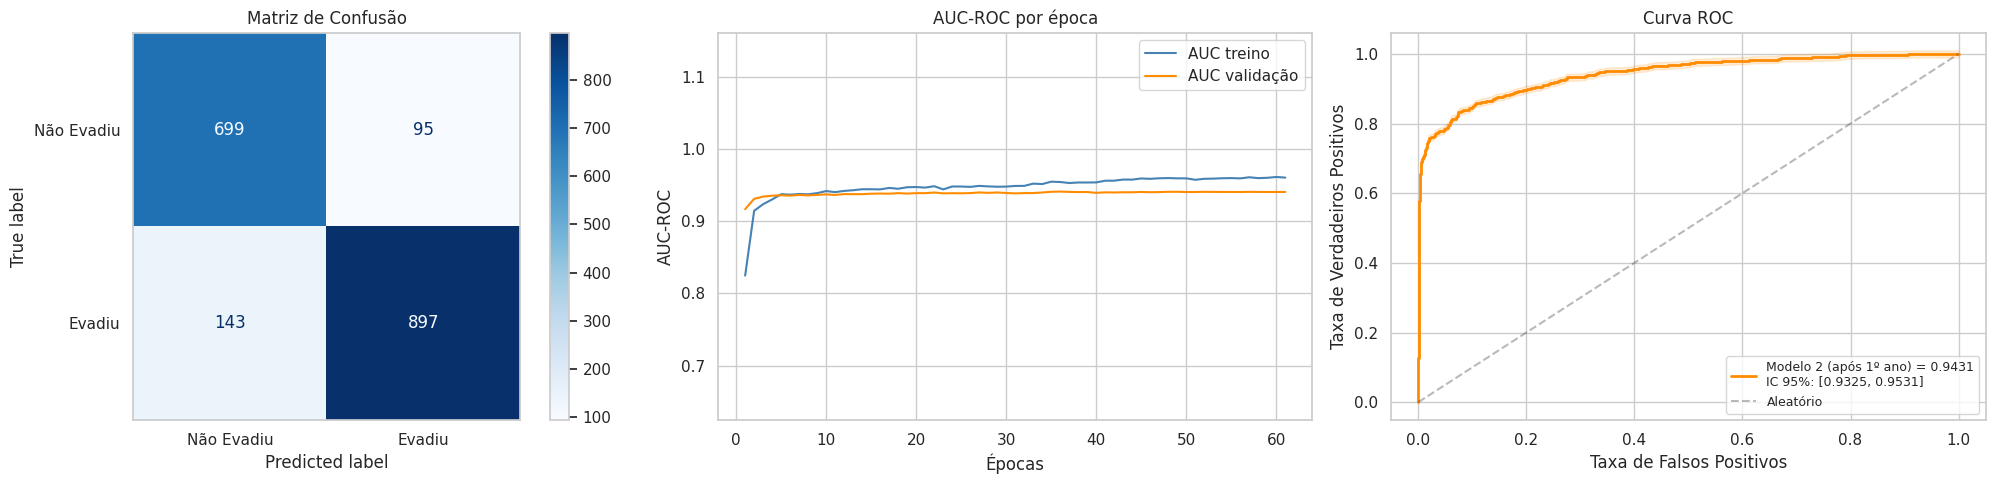

  AUC = 0.9431  IC95%: [0.9325, 0.9531]


In [8]:
# ---------------------------------------------------------
# 8. VISUALIZAÇÕES
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Matriz de confusão
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=['Não Evadiu', 'Evadiu']).plot(
    cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title('Matriz de Confusão')
axes[0].grid(False)

# AUC treino vs validação
epochs_r = range(1, len(history.history['auc_roc']) + 1)
axes[1].plot(epochs_r, history.history['auc_roc'],
             label='AUC treino', color='steelblue')
axes[1].plot(epochs_r, history.history['val_auc_roc'],
             label='AUC validação', color='darkorange')
all_auc = history.history['auc_roc'] + history.history['val_auc_roc']
margin = 0.2
axes[1].set_ylim([min(all_auc) - margin, max(all_auc) + margin])
gap = history.history['auc_roc'][-1] - history.history['val_auc_roc'][-1]
axes[1].set_title(f'AUC-ROC por época')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('AUC-ROC')
axes[1].legend()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
axes[2].plot(fpr, tpr, color='darkorange', linewidth=2,
             label=f'Modelo 2 (após 1º ano) = {roc_auc_m2:.4f}\nIC 95%: [{ci_low:.4f}, {ci_high:.4f}]')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatório')
axes[2].fill_between(fpr,
    np.interp(fpr, fpr, tpr) - (roc_auc_m2 - ci_low),
    np.interp(fpr, fpr, tpr) + (ci_high - roc_auc_m2),
    alpha=0.15, color='darkorange')
axes[2].set_title('Curva ROC')
axes[2].set_xlabel('Taxa de Falsos Positivos')
axes[2].set_ylabel('Taxa de Verdadeiros Positivos')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'resultado_modelo2.png'), dpi=150)
plt.show()

print(f'  AUC = {roc_auc_m2:.4f}  IC95%: [{ci_low:.4f}, {ci_high:.4f}]')